In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from aquarel import load_theme
theme = load_theme('arctic_light')

In [2]:
# 读取 CSV 文件
BASE_DIR = '/mnt/d/幽门螺旋杆菌/Script/分析结果/FST/output/临床指标/AML-阿莫西林'

In [3]:
# df_结果 = pd.read_csv(f'{BASE_DIR}/FST.txt',sep='\t')

In [4]:
# df_结果 = df_结果.T
# df_结果 = df_结果.rename(columns={0:'Fst'})
# df_结果 = df_结果.reset_index()
# df_结果  = df_结果.loc[:,['Fst']]

In [5]:
# df_结果.to_csv(f'{BASE_DIR}/处理后FST.csv', header=True, index_label='Location')

In [6]:
data = pd.read_csv(f'{BASE_DIR}/处理后FST.csv')

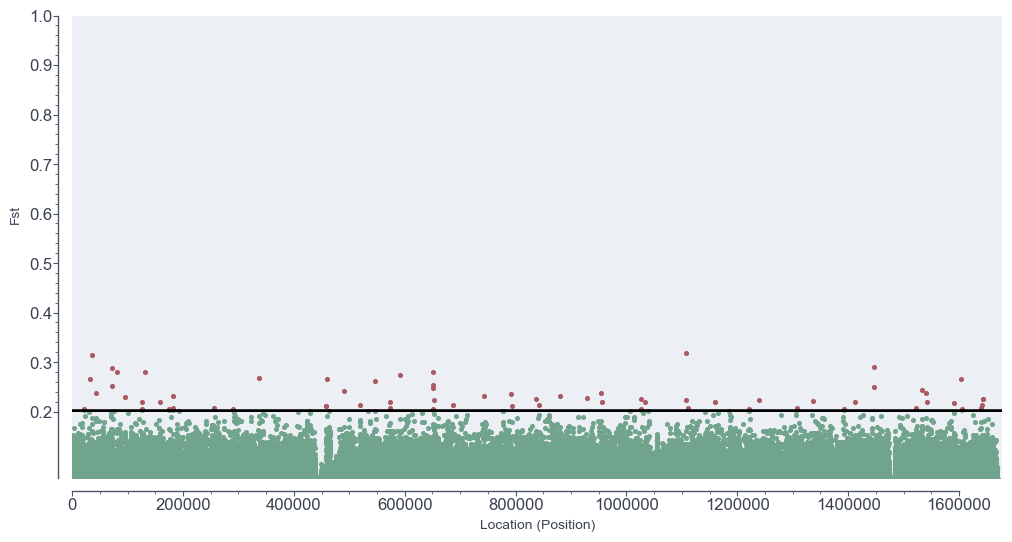

In [16]:
theme.apply()
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
limitation = 0.2

# 1. 构建两个子图；上方: 矢量（除了散点）, 下方: 位图（散点）
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, 
    figsize=(12, 6), 
    sharex=True,  # 共享 x 轴
    gridspec_kw={'height_ratios': [6, 1]}  # 上:下 = 6:1
)
# 消除上下子图之间的空白
plt.subplots_adjust(hspace=0)

# 2. 下方子图 (所有散点栅格化)
scatter_bottom = ax_bottom.scatter(
    data['Location'],  # X 轴使用 Location 列
    data['Fst'],       # Y 轴使用 Fst 列
    c='#71A48D', 
    alpha=1, 
    s=7,
    rasterized=True    # 散点作为位图嵌入 PDF
)
ax_bottom.set_ylim(0, limitation)  # 根据数据的范围调整 y 轴的范围
# 隐藏下图 y 轴刻度
ax_bottom.get_yaxis().set_visible(False)
ax_bottom.set_ylabel('Fst', fontsize=10)
ax_bottom.grid(False)

# 3. 上方子图 (同样将散点栅格化，但其他元素维持矢量)
scatter_top = ax_top.scatter(
    data['Location'],  # X 轴使用 Location 列
    data['Fst'],       # Y 轴使用 Fst 列
    c='#AB5962', 
    alpha=1, 
    s=7,
    rasterized=True    # 这里也设置为位图
)
ax_top.set_ylim(limitation, 1)  # 根据数据的范围调整 y 轴的范围
ax_top.set_ylabel('Fst', fontsize=10)
ax_top.grid(False)
# 隐藏上图 x 轴的刻度和轴线
ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax_top.spines['bottom'].set_visible(False)
# 添加一条在 y=limitation 处的平行于 X 轴的黑色线条（该 line 保持矢量）
ax_top.axhline(y=limitation, color='black', linewidth=4, alpha=1, linestyle='-')

# 4. 公共设置
ax_bottom.set_xlabel('Location (Position)', fontsize=10)
ax_bottom.set_title('')
ax_bottom.set_xlim(left=0, right=data['Location'].max() + 10000)
ax_bottom.ticklabel_format(style='plain', axis='x')  # 关闭科学计数法

# 保存图形为 PDF（散点作为位图嵌入，坐标轴等仍为矢量）
import os
theme.apply_transforms()

plt.savefig(f'{BASE_DIR}/FST.pdf',dpi=500)
plt.show()


In [8]:
import pandas as pd

# 读取Fst数据，假设 data 变量已经是一个 DataFrame
fst_data = data

# 提取 Fst 大于 0.5 的记录，并构建位置到 Fst 值的映射字典
fst_threshold = limitation
high_fst = fst_data[fst_data['Fst'] > fst_threshold]
high_fst_positions = high_fst['Location'].tolist()
fst_dict = high_fst.set_index('Location')['Fst'].to_dict()

# 读取GFF文件
gff_file = '/mnt/d/幽门螺旋杆菌/Script/分析结果/FST/script/R方法/NC_000915.gff'  # 替换为实际的GFF文件路径
with open(gff_file, 'r') as gff:
    gff_lines = gff.readlines()

# 输出结果的路径
output_file = f'{BASE_DIR}/注释.txt'

# 存储结果
results = []

# 遍历GFF文件，查找 CDS 注释行中包含的物理位置
for line in gff_lines:
    columns = line.strip().split('\t')
    
    # 过滤出 CDS 类型的注释行
    if len(columns) > 4 and columns[2] == "CDS":
        start = int(columns[3])
        end = int(columns[4])
        
        # 如果 Fst 的物理位置在 CDS 区域内
        for pos in high_fst_positions:
            if start <= pos <= end:
                fst_value = fst_dict.get(pos, None)
                product = columns[2]      # 这里 columns[2] 为 CDS
                annotation = columns[8]   # 注释信息在最后一列
                results.append(f"位置: {pos}, Fst: {fst_value}, 编码产物: {product}, 注释: {annotation}")

# 将结果写入文件
with open(output_file, 'w') as output:
    for result in results:
        output.write(result + '\n')

print(f"差异分析结果已输出到 {output_file}")


差异分析结果已输出到 /mnt/d/幽门螺旋杆菌/Script/分析结果/FST/output/临床指标/AML-阿莫西林/注释.txt


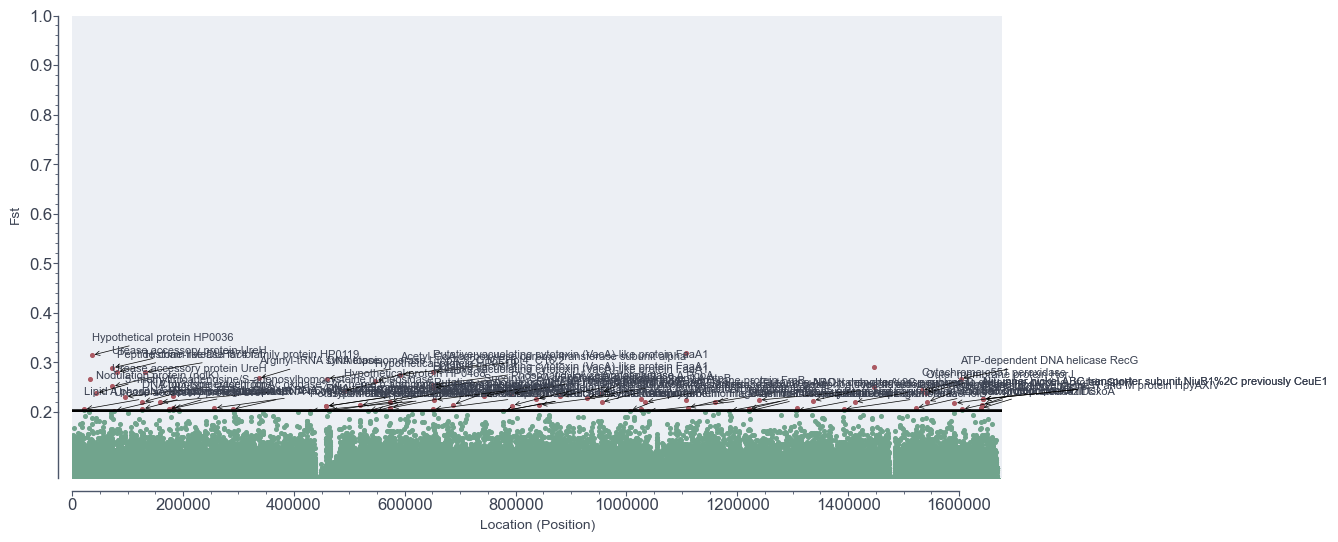

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 假设 data 已经提前读取并包含 'Location' 和 'Fst' 两列
# limitation 也已在外部定义，例如 limitation = 0.2

# 设置主题和字体
theme.apply()
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# 1. 构建两个子图；上方: 矢量（散点同为位图），下方: 位图
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(12, 6),
    sharex=True,                   # 共享 x 轴
    gridspec_kw={'height_ratios': [6, 1]}  # 上:下 = 6:1
)
plt.subplots_adjust(hspace=0)       # 消除上下子图之间的空白

# 2. 下方子图 (散点完全栅格化)
scatter_bottom = ax_bottom.scatter(
    data['Location'],  # X 轴使用 Location 列
    data['Fst'],       # Y 轴使用 Fst 列
    c='#71A48D',
    alpha=1,
    s=7,
    rasterized=True    # 将散点栅格化（嵌入位图）
)
ax_bottom.set_ylim(0, limitation)  # 根据数据的范围调整 y 轴范围
ax_bottom.get_yaxis().set_visible(False)  # 隐藏下图 y 轴刻度
ax_bottom.set_ylabel('Fst', fontsize=10)
ax_bottom.grid(False)

# 3. 上方子图 (散点同样栅格化；其余元素保持矢量)
scatter_top = ax_top.scatter(
    data['Location'],  # X 轴使用 Location 列
    data['Fst'],       # Y 轴使用 Fst 列
    c='#AB5962',
    alpha=1,
    s=7,
    rasterized=True    # 将散点栅格化
)
ax_top.set_ylim(limitation, 1)   # 根据数据的范围调整 y 轴范围
ax_top.set_ylabel('Fst', fontsize=10)
ax_top.grid(False)

# 隐藏上图 x 轴的刻度和轴线（仅保留顶部的文字/箭头/annotation）
ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax_top.spines['bottom'].set_visible(False)

# 添加一条在 y=limitation 处的平行于 X 轴的黑色矢量线
ax_top.axhline(
    y=limitation,
    color='black',
    linewidth=4,
    alpha=1,
    linestyle='-'
)

# 4. 公共设置
ax_bottom.set_xlabel('Location (Position)', fontsize=10)
ax_bottom.set_title('')
ax_bottom.set_xlim(left=0, right=data['Location'].max() + 10000)
ax_bottom.ticklabel_format(style='plain', axis='x')  # 关闭科学计数法

# ======================================================
# 以下为新增部分：仅对 Fst > limitation 的位点标记对应 CDS 注释中的 product 信息

# 筛选 Fst 大于阈值的数据用于注释标记
annotation_threshold = limitation
annotate_data = data[data['Fst'] > annotation_threshold]

# 读取 GFF 文件，提取 CDS 区间及其注释中的 product 信息
gff_file = '/mnt/d/幽门螺旋杆菌/Script/分析结果/FST/script/R方法/NC_000915.gff'  # 根据实际路径修改
cds_list = []
with open(gff_file, 'r') as gff:
    for line in gff:
        if line.startswith("#"):
            continue
        cols = line.strip().split('\t')
        if len(cols) > 2 and cols[2] == "CDS":
            start = int(cols[3])
            end   = int(cols[4])
            annotation_field = cols[8]
            # 按分号分割后取最后一段，并提取 "product=" 后面的内容
            fields = annotation_field.split(';')
            last_field = fields[-1].strip()
            if last_field.startswith('product='):
                product_info = last_field[len('product='):]
            else:
                product_info = last_field
            cds_list.append((start, end, product_info))

# 遍历 Fst > limitation 的位点，检查是否落在某个 CDS 区间内，若是则在上图上标注 product 信息
for idx, row in annotate_data.iterrows():
    pos = row['Location']
    fst_value = row['Fst']
    for (start, end, product_info) in cds_list:
        if start <= pos <= end:
            # 这里的注释文字和箭头都是矢量对象，可在 PDF 中任意编辑
            ax_top.annotate(
                product_info,
                xy=(pos, fst_value),
                xytext=(pos, min(fst_value + 0.03, 1)),
                arrowprops=dict(arrowstyle="->", color='black', lw=0.5),
                fontsize=8
            )
            break
# ======================================================

# 应用主题的后处理，然后保存为 PDF
theme.apply_transforms()
plt.savefig(f'{BASE_DIR}/FST_注释.pdf',dpi=500)
plt.show()
